# **SQL Basics**

1. Create a table called employees with the following structure?

: emp_id (integer, should not be NULL and should be a primary key).

: emp_name (text, should not be NULL).

: age (integer, should have a check constraint to ensure the age is at least 18).

: email (text, should be unique for each employee).

: salary (decimal, with a default value of 30,000).

Write the SQL query to create the above table with all constraints.

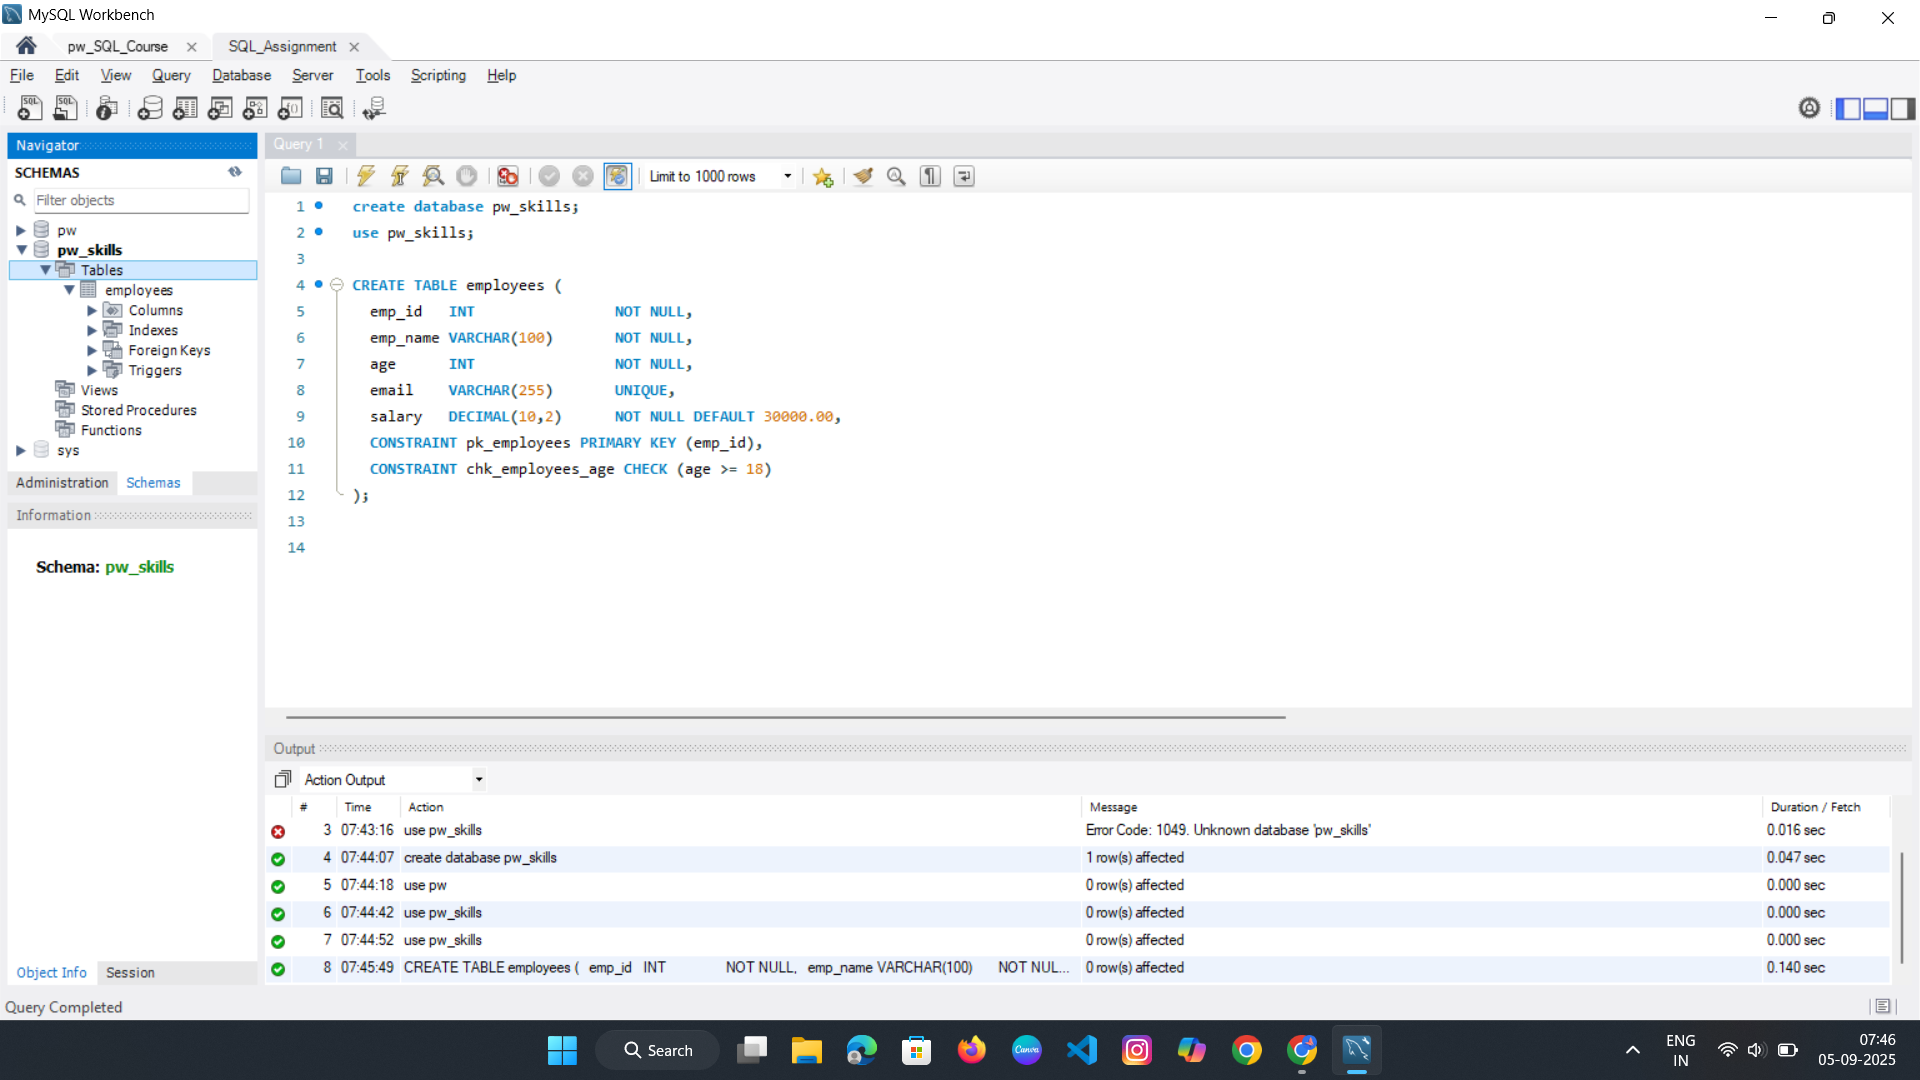

2. Explain the purpose of constraints and how they help maintain data integrity in a database. Provide examples of common types of constraints.

Purpose of constraints (with examples)

Why constraints?

They enforce rules at the database level so bad data can’t get in—protecting integrity regardless of the app code.

Common types

PRIMARY KEY: uniquely identifies each row.

PRIMARY KEY (emp_id)

FOREIGN KEY: enforces valid references between tables.

FOREIGN KEY (dept_id) REFERENCES departments(dept_id)

UNIQUE: no duplicates allowed.

UNIQUE (email)

NOT NULL: value must be provided.

emp_name VARCHAR(100) NOT NULL

CHECK: boolean rule per row.

CHECK (age >= 18)

DEFAULT: fills in a value when omitted.

salary DECIMAL(10,2) DEFAULT 30000.00

3.Why would you apply the NOT NULL constraint to a column? Can a primary key contain NULL values? Justify your answer.

- NOT NULL stops missing/unknown values for required columns (e.g., names, amounts).

- Primary keys cannot contain NULLs—by definition, a Primary Key must uniquely identify every row, and NULL means “unknown,” which breaks identity and indexing semantics.

4. Explain the steps and SQL commands used to add or remove constraints on an existing table. Provide an example for both adding and removing a constraint.

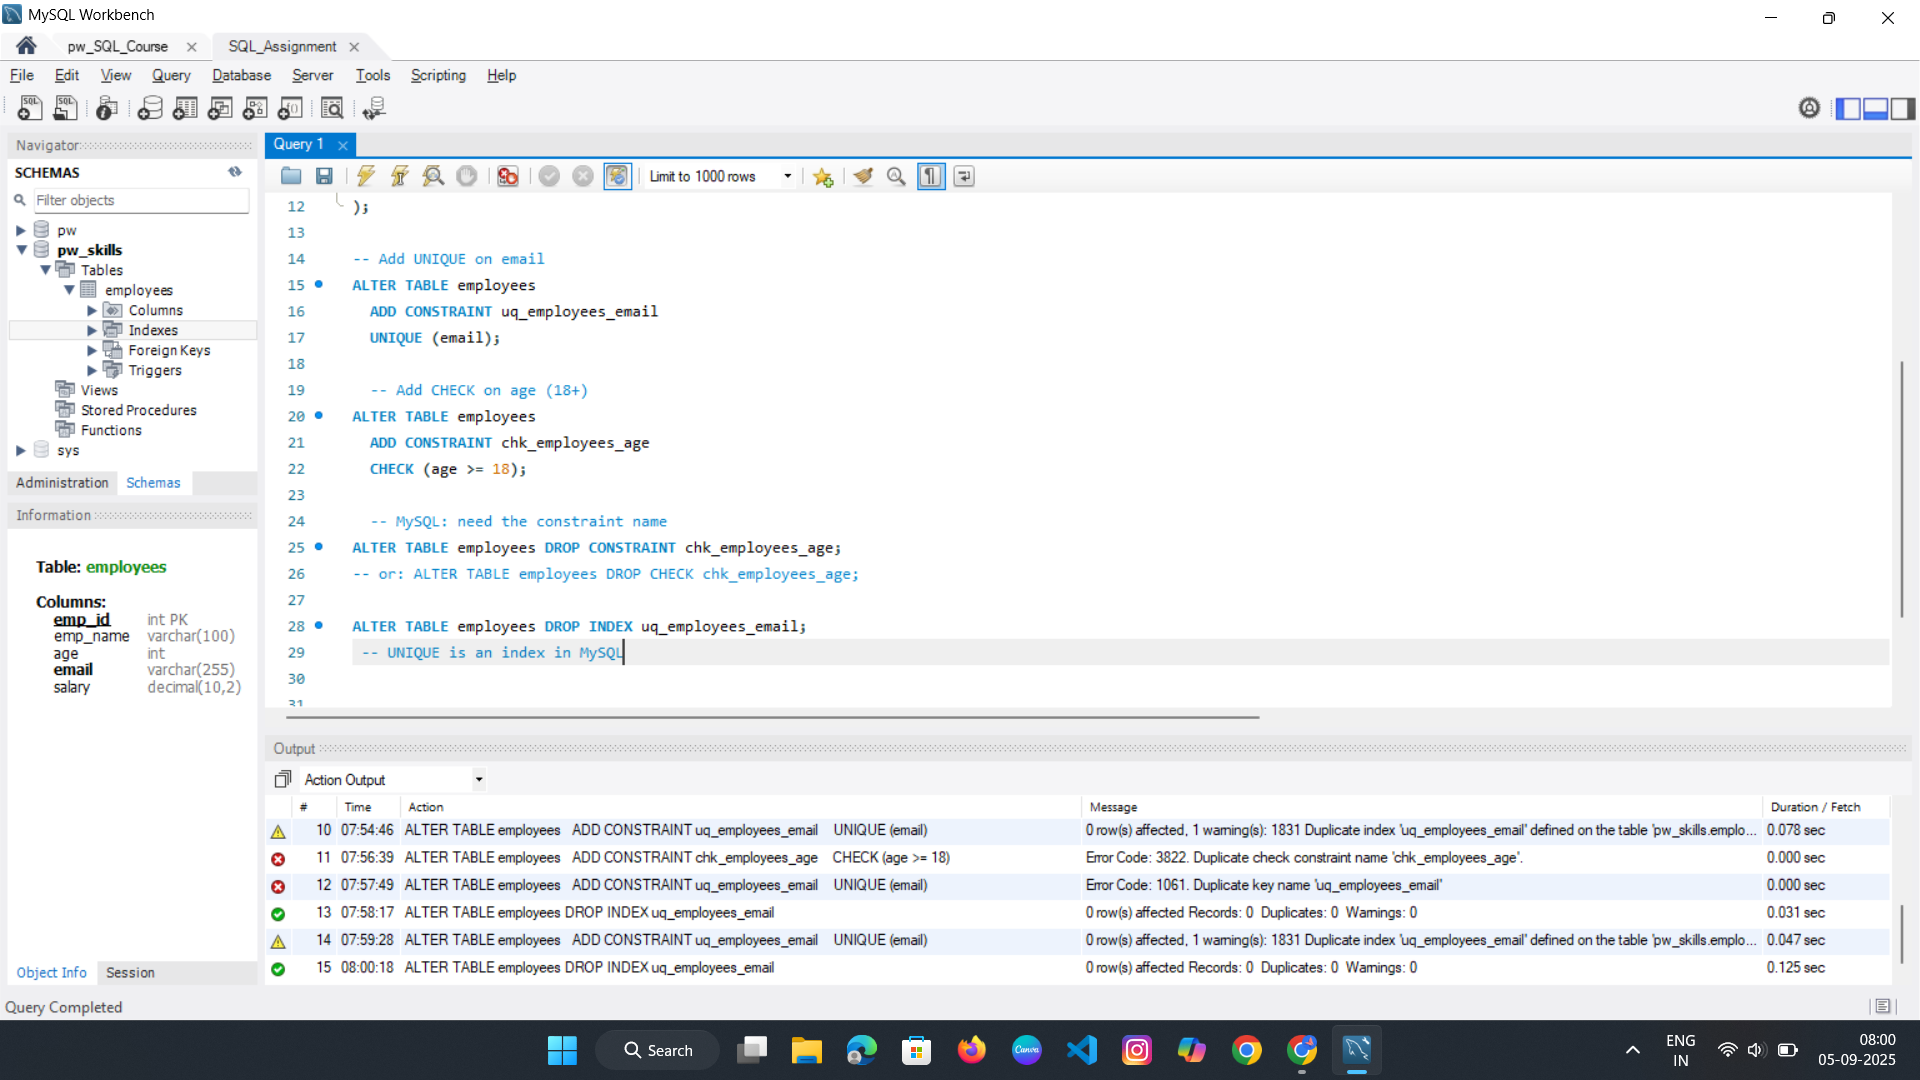

5. Explain the consequences of attempting to insert, update, or delete data in a way that violates constraints. Provide an example of an error message that might occur when violating a constraint.

The statement fails, no row change is committed, and you get an error.

 Examples:

Insert age < 18 ⇒ fails CHECK.

Duplicate email ⇒ fails UNIQUE.

NULL in emp_name ⇒ fails NOT NULL.

Invalid foreign key ⇒ fails FOREIGN KEY.

#Example message (MySQL, UNIQUE)

ERROR 1062 (23000): Duplicate entry 'a@b.com' for key 'employees.uq_employees_email'


6. You created a products table without constraints as follows:

CREATE TABLE products (

   product_id INT,

   product_name VARCHAR(50),

   price DECIMAL(10, 2));

Now, you realise that?

: The product_id should be a primary key

: The price should have a default value of 50.00

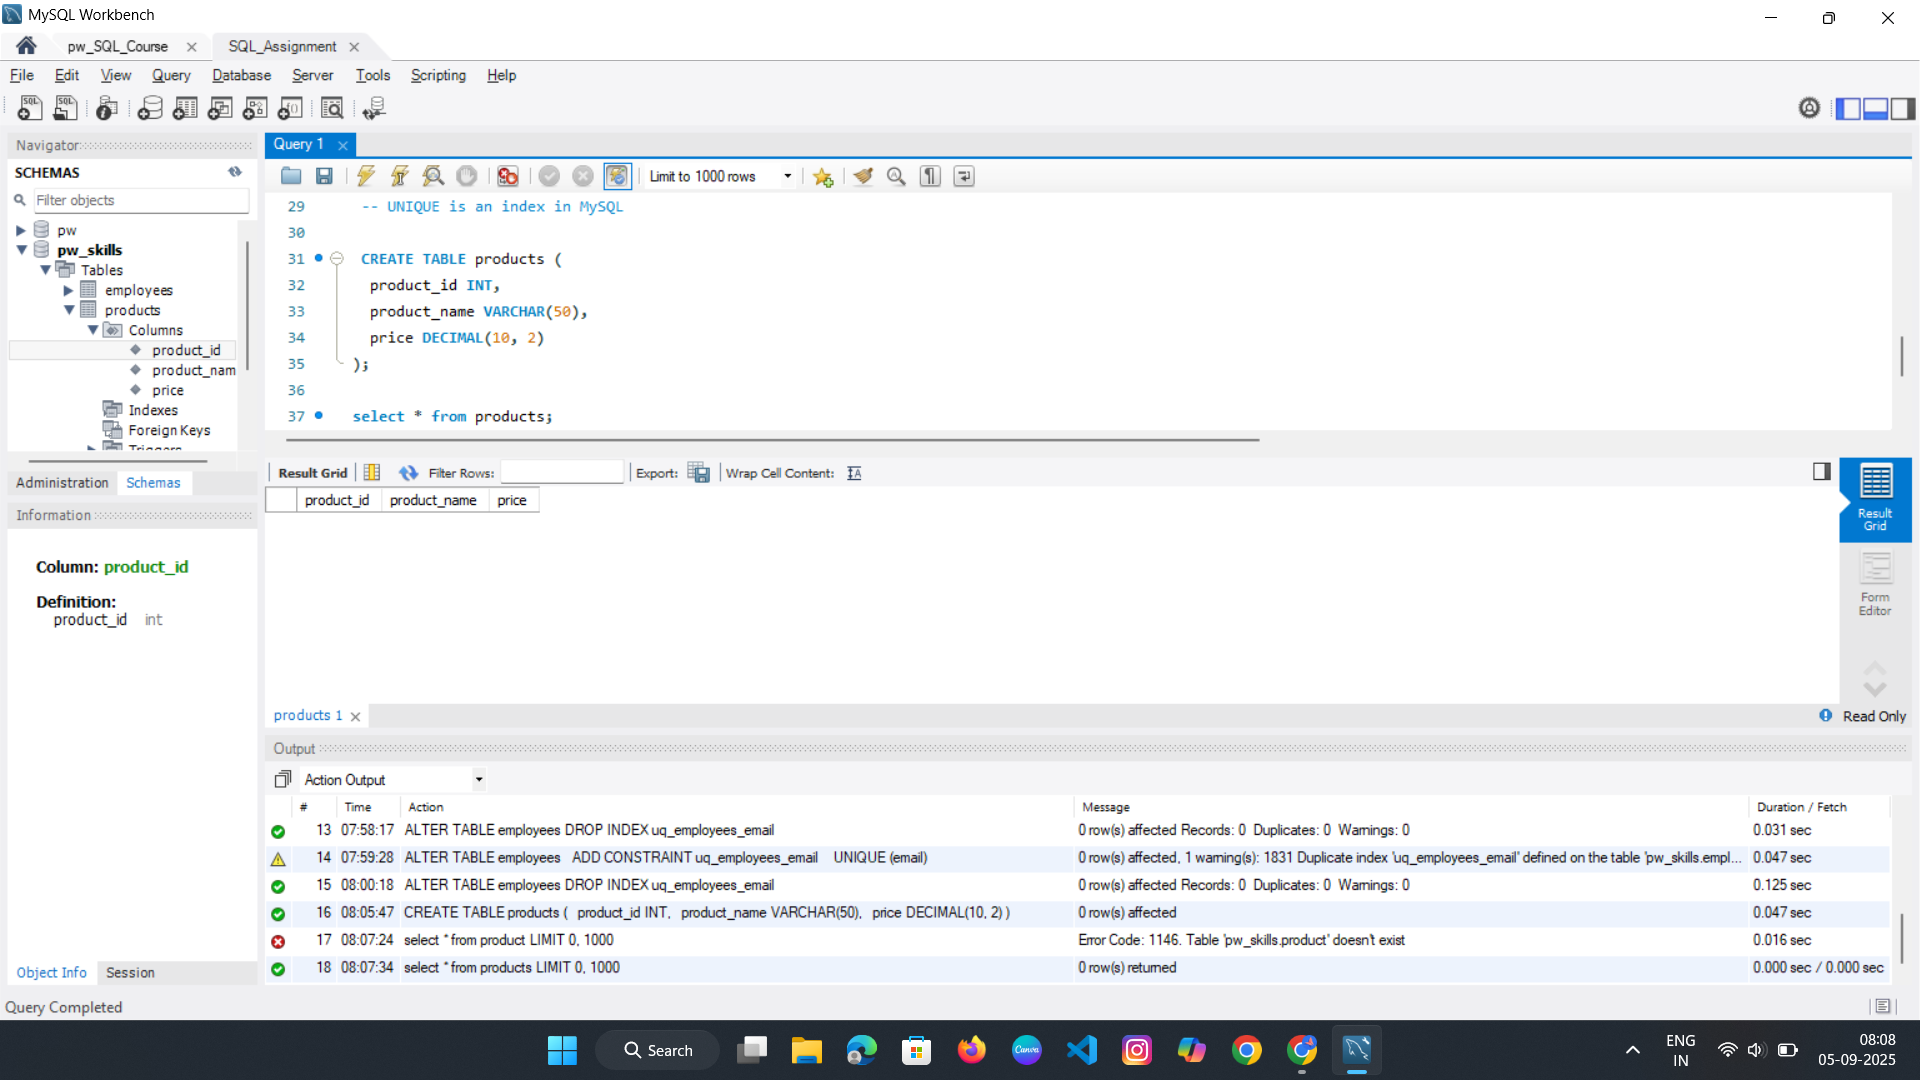

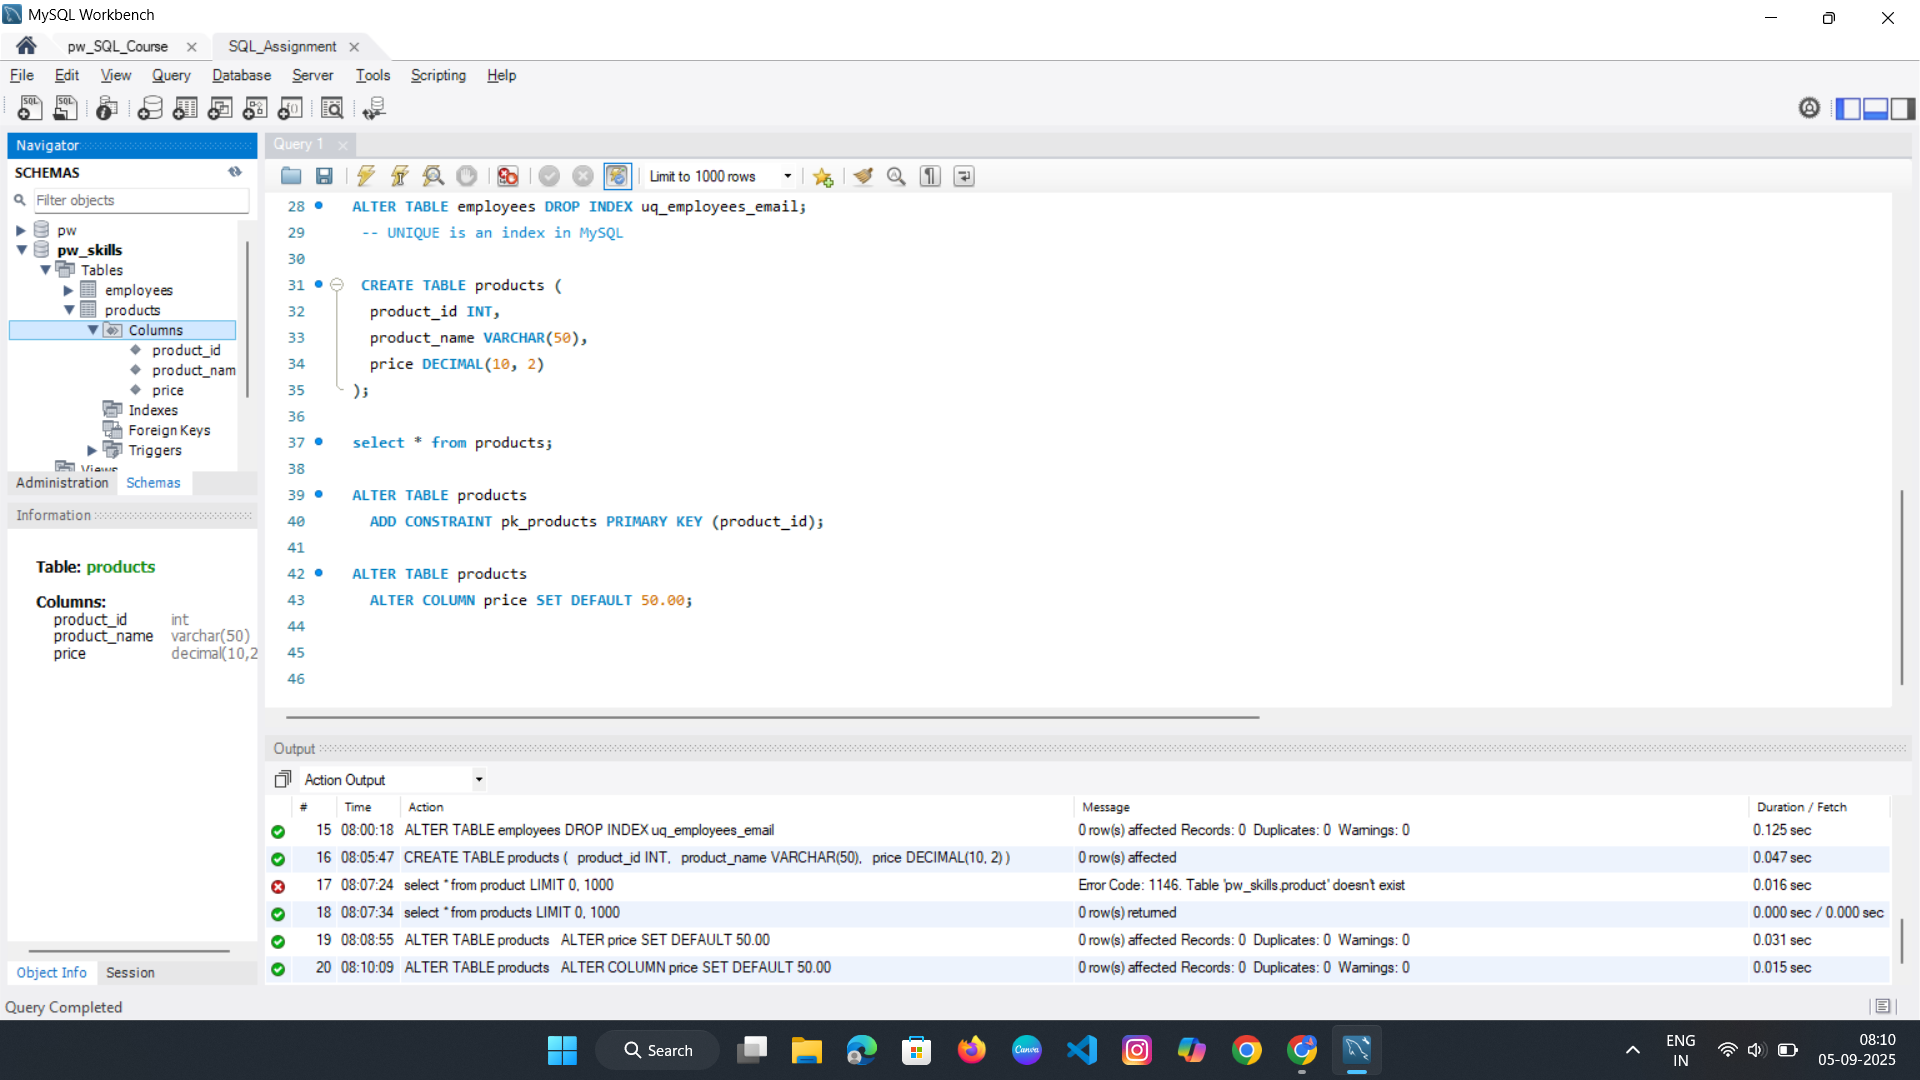

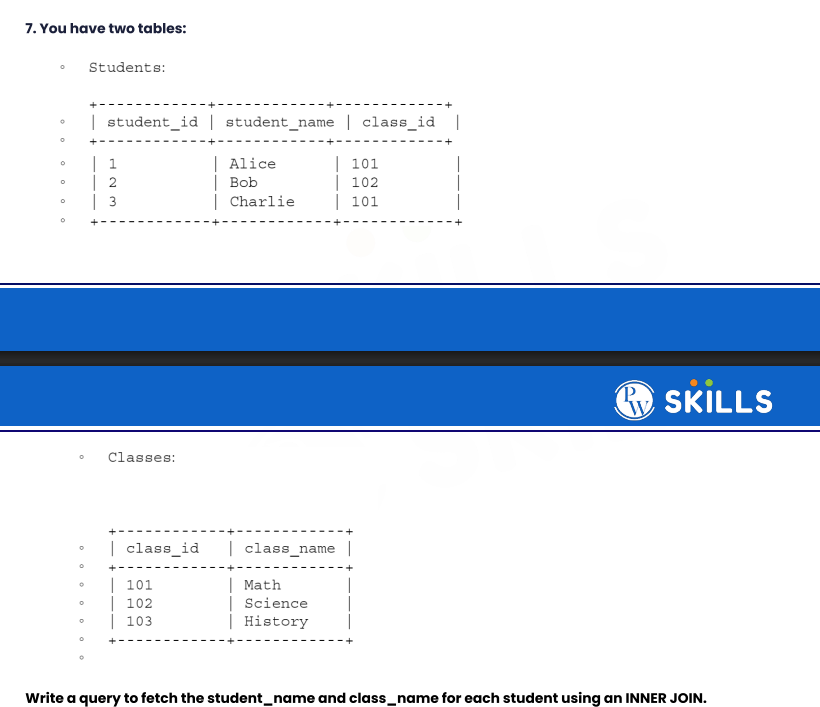

#SQL Query
SELECT s.student_name, c.class_name

FROM Students s

INNER JOIN Classes c

ON s.class_id = c.class_id;

INNER JOIN matches rows from Students and Classes where class_id is the same in both tables.

Only students with a valid class match will appear.

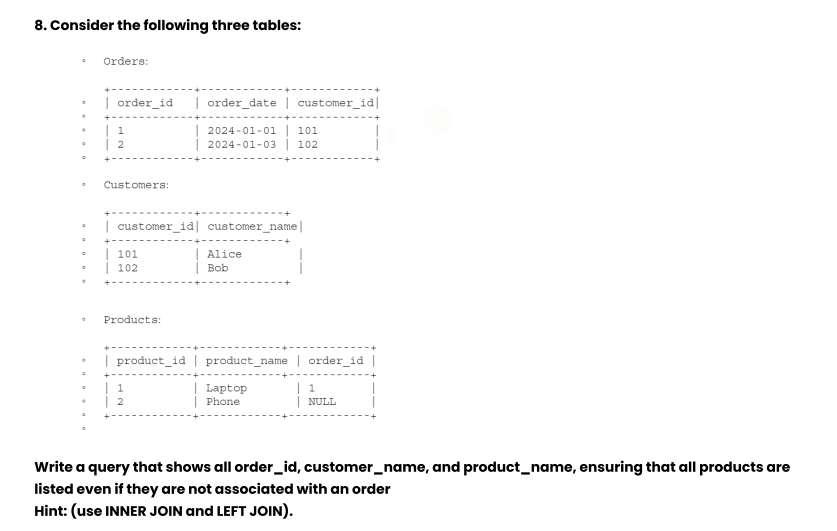

#Assumed tables:
orders(order_id, customer_id, order_date)

customers(customer_id, customer_name)

order_items(order_id, product_id, quantity)

products(product_id, product_name)

SELECT

  o.order_id,
  
  c.customer_name,

  p.product_name

FROM products p

LEFT JOIN order_items oi ON oi.product_id = p.product_id

LEFT JOIN orders o       ON o.order_id   = oi.order_id

LEFT JOIN customers c    ON c.customer_id= o.customer_id

ORDER BY p.product_name, o.order_id;


**LEFT JOIN from products ensures all products appear, even if not in any order.**

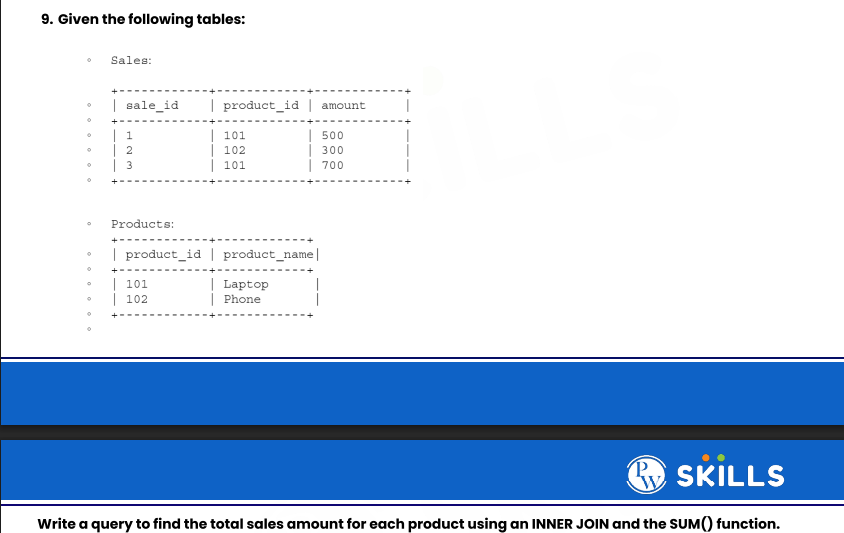

In [ ]:
SELECT
  p.product_id,
  p.product_name,
  SUM(oi.quantity * oi.unit_price) AS total_sales_amount
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
GROUP BY p.product_id, p.product_name
ORDER BY total_sales_amount DESC;

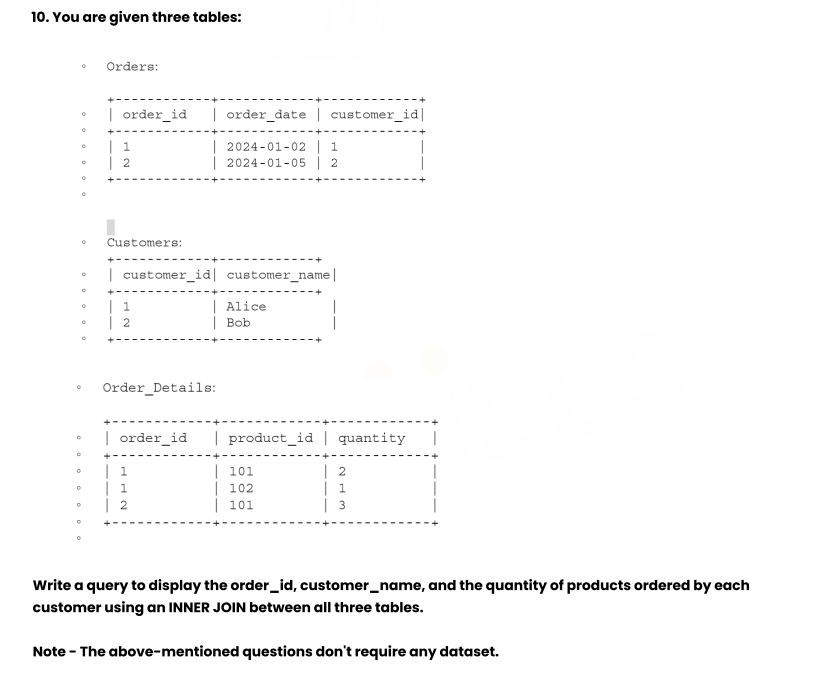

In [ ]:
SELECT
  o.order_id,
  c.customer_name,
  SUM(oi.quantity) AS total_quantity
FROM orders o
JOIN customers c  ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
GROUP BY o.order_id, c.customer_name
ORDER BY o.order_id;
